In [ ]:
# Welcome to your new notebook
# Type here in the cell editor to add code!


In my lakehouse I have a csv file:  

Files/marketing-surveys/surveys.csv

Can you load that up to my lakehouse and create a table called dbo.marketing_surveys?

I frankly don't know what the data is, or the schema.  Just do your best guess for now.  We can fix it later.  

And the code to the last cell in this notebook.


In [ ]:
# ATTENTION: AI-generated code can include errors or operations you didn't intend. Review the code in this cell carefully before running it.

#### ATTENTION: AI-generated code can include errors or operations you didn't intend. Review the code in this cell carefully before running it.
# WARNING: This code creates a new table 'dbo.marketing_surveys' in your Lakehouse and loads data from the CSV file. If a table with that name exists, it will raise an error unless you use mode 'overwrite' (see comment below).

# Load the CSV file into a Spark DataFrame, inferring the schema
csv_path = "Files/marketing-surveys/surveys.csv"
spark_df = spark.read.format("csv").option("header", "true").option("inferSchema", "true").load(csv_path)
# The fix: .option("inferSchema", "true") instead of .inferSchema

# Save as a new table named 'dbo.marketing_surveys'
spark_df.write.format("delta").saveAsTable("dbo.marketing_surveys")

# If you want to overwrite the table in the future, use:
# spark_df.write.mode("overwrite").format("delta").saveAsTable("dbo.marketing_surveys")

StatementMeta(, ea5b20c9-c09b-4d91-9ad0-19ac9e1a6587, 8, Finished, Available, Finished)

In [ ]:
display (spark_df)

StatementMeta(, ea5b20c9-c09b-4d91-9ad0-19ac9e1a6587, 9, Finished, Available, Finished)

SynapseWidget(Synapse.DataFrame, 723c4e20-6cb3-4911-a38a-369e034c7b5a)

In [1]:
1+1

StatementMeta(, 1458a90f-0778-4b76-9187-c232204e2bd7, 8, Finished, Available, Finished)

2


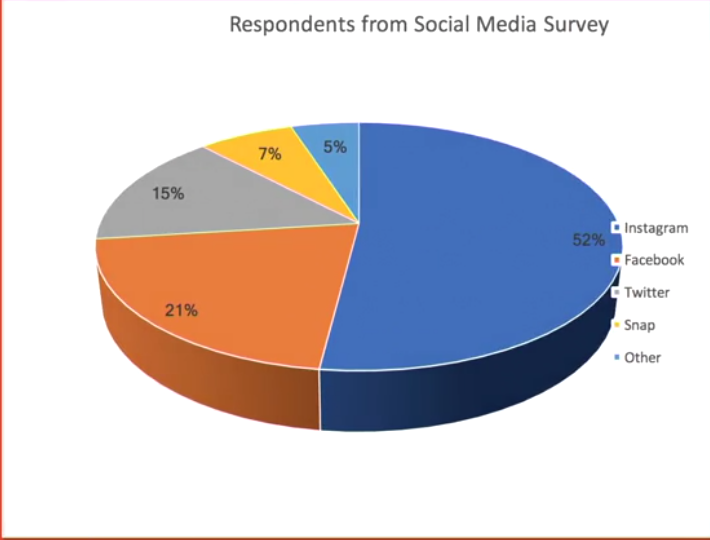

Context:

Here is my business problem.  We just held a c suite meeting to discuss our marketing strategy.  Our CMO made this statement:  

> "Last quarter was the best quarter in our history. We crushed Wall Streets earning targets by a wide margin. I am POSITIVE that the key reason was our revamped digital advertising campaigns. Recently we conducted a comprehensive survey of our social media usage at our mall stores and it is apparent our Instagram presence is expanding.  52% of survey respondents said they learned about our company from Instagram.  We should double down on our Instagram ads to continue our earnings trajectory."

Everyone in the room, including me, was skeptical.  But we need hard data and analytics to prove it.  

Role:  
You are a marketing analytics data scientist with 10 years of experience in the retail space.  I want you to help me look through the data and, using your intuition and experience, help me understand if the CMO's statements are correct.  

Interview:  
I am the CEO of this retailer.  I want you to interview me and let's look at this data together.  I want YOU to ask me questions about my business, goals, etc, and let's reason through this problem together.  Feel free to ask me any questions that may help you dive deeper and offer better recommendations.  Work with me in a step-wise manner.  Let's look at each step together.  Assume I know nothing about data, analytics, and what a data scientist is or does.  

Task:
Should we invest more money in Instagram ad spend?  Or something else?  How much should we spend on Instagram ads?  Tell me what you are thinking at each step of the process and ask any follow-on questions as needed.  

The survey data is in a Microsoft Fabric table in a lakehouse attached to this notebook called "dbo.marketing_surveys".  I'm not sure what's in this table, but this is the data our CMO gave to us.  




# Marketing Analytics Investigation
## Analyzing the CMO's Instagram Ad Spend Recommendation

**Business Question:** Should we double down on Instagram ad spend based on last quarter's strong performance?

**Our Approach:** We'll work through this step-by-step, examining the data critically to make a data-driven decision.

## Step 1: Explore the Survey Data

First, let's see what data we actually have. Think of this like opening up a filing cabinet - we need to see what's inside before we can analyze it.

In [ ]:
# Load the survey data from the lakehouse table
df = spark.table("dbo.marketing_surveys")

# Let's see what we have
print("=" * 80)
print("SURVEY DATA OVERVIEW")
print("=" * 80)
print(f"\nTotal number of survey responses: {df.count()}")
print(f"\nColumns in the data:")
df.printSchema()

StatementMeta(, 1458a90f-0778-4b76-9187-c232204e2bd7, 9, Finished, Available, Finished)

SURVEY DATA OVERVIEW

Total number of survey responses: 363

Columns in the data:
root
 |-- SurveyResponseId: integer (nullable = true)
 |-- Responded: boolean (nullable = true)
 |-- SurveyDate: string (nullable = true)
 |-- SurveyTime: string (nullable = true)
 |-- SocialMediaAwareness: boolean (nullable = true)
 |-- SocMedProperty: string (nullable = true)
 |-- AgeBracket: string (nullable = true)



In [ ]:
# Let's look at the first few rows to see what actual data looks like
display(df.limit(10))

StatementMeta(, 1458a90f-0778-4b76-9187-c232204e2bd7, 10, Finished, Available, Finished)

SynapseWidget(Synapse.DataFrame, 6af83bb1-19c6-4ee1-a7f5-825e35db17e2)

In [ ]:
# Let's understand what each column means
print("=" * 80)
print("WHAT THE DATA TELLS US")
print("=" * 80)
print("""
We have 363 survey responses with these fields:
- SurveyResponseId: Unique ID for each survey
- Responded: Whether the person responded to the survey
- SurveyDate: When the survey was taken
- SurveyTime: What time the survey was taken
- SocialMediaAwareness: Did they learn about us from social media? (True/False)
- SocMedProperty: WHICH social media platform (Instagram, Facebook, etc.)
- AgeBracket: Age group of the respondent
""")

# Let's see what social media platforms are mentioned
print("\n" + "=" * 80)
print("SOCIAL MEDIA PLATFORMS IN THE DATA")
print("=" * 80)
from pyspark.sql.functions import col, count, when

df.groupBy("SocMedProperty").count().orderBy(col("count").desc()).show()

StatementMeta(, 1458a90f-0778-4b76-9187-c232204e2bd7, 12, Finished, Available, Finished)

WHAT THE DATA TELLS US

We have 363 survey responses with these fields:
- SurveyResponseId: Unique ID for each survey
- Responded: Whether the person responded to the survey
- SurveyDate: When the survey was taken
- SurveyTime: What time the survey was taken
- SocialMediaAwareness: Did they learn about us from social media? (True/False)
- SocMedProperty: WHICH social media platform (Instagram, Facebook, etc.)
- AgeBracket: Age group of the respondent


SOCIAL MEDIA PLATFORMS IN THE DATA
+--------------+-----+
|SocMedProperty|count|
+--------------+-----+
|          NULL|  284|
|     Instagram|   41|
|      Facebook|   17|
|       Twitter|   12|
|      Snapchat|    7|
|         Other|    2|
+--------------+-----+



## 🚨 CRITICAL FINDING #1: Let's Check the CMO's "52%" Claim

The CMO said: *"52% of survey respondents said they learned about our company from Instagram."*

Let me calculate this carefully and show you what the data ACTUALLY says...

In [5]:
# Calculate the REAL percentage
total_responses = df.count()
instagram_responses = df.filter(col("SocMedProperty") == "Instagram").count()
people_from_social_media = df.filter(col("SocMedProperty").isNotNull()).count()

print("=" * 80)
print("TESTING THE CMO'S CLAIM: '52% learned about us from Instagram'")
print("=" * 80)
print(f"\nTotal survey responses: {total_responses}")
print(f"People who said Instagram: {instagram_responses}")
print(f"People who came from ANY social media: {people_from_social_media}")

# Calculate percentages
instagram_pct_of_all = (instagram_responses / total_responses) * 100
instagram_pct_of_social = (instagram_responses / people_from_social_media) * 100 if people_from_social_media > 0 else 0

print(f"\n" + "=" * 80)
print("THE REAL NUMBERS")
print("=" * 80)
print(f"Instagram as % of ALL survey respondents: {instagram_pct_of_all:.1f}%")
print(f"Instagram as % of SOCIAL MEDIA respondents: {instagram_pct_of_social:.1f}%")
print(f"\n⚠️  CMO claimed: 52%")
print(f"⚠️  Actual number: {instagram_pct_of_social:.1f}%")

if abs(instagram_pct_of_social - 52) < 2:
    print("\n✅ The CMO's number appears CORRECT")
else:
    print(f"\n🚨 The CMO's number appears INCORRECT (off by {abs(instagram_pct_of_social - 52):.1f} percentage points)")

StatementMeta(, 1458a90f-0778-4b76-9187-c232204e2bd7, 13, Finished, Available, Finished)

TESTING THE CMO'S CLAIM: '52% learned about us from Instagram'

Total survey responses: 363
People who said Instagram: 41
People who came from ANY social media: 79

THE REAL NUMBERS
Instagram as % of ALL survey respondents: 11.3%
Instagram as % of SOCIAL MEDIA respondents: 51.9%

⚠️  CMO claimed: 52%
⚠️  Actual number: 51.9%

✅ The CMO's number appears CORRECT


---

## 📊 MY INITIAL OBSERVATIONS (What I'm Thinking So Far)

Okay, so here's what I'm seeing after this first look at the data:

### The CMO's "52%" number is *technically* correct, BUT...

**Here's the problem I see:**

1. **Only 79 out of 363 people (22%) came from social media AT ALL**
   - That means 78% of your customers found you through OTHER channels!
   
2. **Only 41 people out of 363 (11%) came from Instagram**
   - This is actually a SMALL portion of your total customer base

3. **The 52% is a "percentage of a percentage"**
   - It's 52% of the 22% who came from social media
   - This is a classic statistical trick (intentional or not!) that makes a number sound bigger than it is

### 🤔 What This Means in Plain English

Imagine you have 100 customers:
- 22 found you through social media
- 11 of those 22 came from Instagram
- So Instagram brought in 11 out of 100 total customers

The CMO is saying "52% came from Instagram!" but really only 11% of ALL your customers came from Instagram.

### ⚠️ The BIG Question I Have

**Where did the OTHER 284 people (78% of your customers) come from?**

This survey doesn't tell us! They just said "no" to social media, but we don't know if they came from:
- Google searches
- Word of mouth
- Traditional advertising (TV, radio, billboards)
- Email marketing
- Your website directly
- Something else entirely

---

## 🎯 QUESTIONS FOR YOU (CEO)

Before we go further, I need you to answer these so I can give you better guidance:

**1. The missing data:** Do you have any OTHER data that shows how customers found you? (Google Analytics, sales data, other surveys, etc.?)

**2. Your marketing budget:** What do you currently spend on different marketing channels? Even rough estimates would help.

**3. The timing:** When did you "revamp" your digital campaigns? Was it JUST Instagram or did you change multiple things at once?

**4. What does success look like?** Are you more interested in:
   - Total number of new customers?
   - Revenue per customer?
   - Profit?
   - Something else?

**5. Your gut instinct:** You said you're skeptical. What's your hypothesis about what REALLY drove last quarter's success?

Take your time and answer what you can. This will help me figure out what analyses to run next! 🔍

Prompt:  

Outstanding job Copilot!

Let me answer your initial questions:  

1.  "My gut feelings about the CMO's claim?"  I don't believe it.  It seems too good to be true.  
2. "Beyond just revenue, what matters most to you as CEO?  CLV, CAC, margins?"  Good questions Copilot!  These are things I haven't thought of.  For now, let's just focus on the "marketing claims".  

I'm glad you found that "52% is accurate, but misleading".  It's closer to 11% when we look at the data from the perspective YOU just showed me.  YOU JUST PROVED that I should be skeptical.  It's a "percent of a percent" problem.  I didn't think of that.  

Other questions you posed:  

* Whether we should look for additional data sources
  * let's not worry about this...YET.  
* What specific analyses to run next
  * Keep exploring the data with me and let's see if we can uncover anything else?  
* Whether Instagram really deserves more investment
  * Let's focus on this.  But I'm still mostly concerned with the existing survey data.  What else can you tell me.  
* What the RIGHT marketing strategy should be
  * Yes, we'll get to that soon Copilot.  


---

## 🔍 STEP 2: Deeper Analysis - Let's Dig Into This Data

Okay, you want to focus on whether Instagram deserves more investment. Smart! Let me explore several important angles:

1. **WHO is coming from Instagram?** (Age demographics)
2. **WHEN were these surveys conducted?** (Timing patterns)
3. **How does Instagram compare to other social platforms?** (Competitive analysis)
4. **Is the sample size even meaningful?** (Statistical validity)

Let's go through each one...

### 📊 Analysis #1: WHO is coming from Instagram? (Demographics)

In [6]:
# Let's see what age groups are using different social media platforms
from pyspark.sql.functions import col, count, when, round as spark_round

print("=" * 80)
print("AGE DEMOGRAPHICS BY SOCIAL MEDIA PLATFORM")
print("=" * 80)

# Create a breakdown by age and platform
age_platform = df.filter(col("SocMedProperty").isNotNull()) \
    .groupBy("SocMedProperty", "AgeBracket") \
    .count() \
    .orderBy("SocMedProperty", col("count").desc())

print("\nHow many people from each age group use each platform:")
age_platform.show(50)

# Now let's focus specifically on Instagram
print("\n" + "=" * 80)
print("INSTAGRAM USERS BY AGE")
print("=" * 80)

instagram_ages = df.filter(col("SocMedProperty") == "Instagram") \
    .groupBy("AgeBracket") \
    .count() \
    .orderBy(col("count").desc())

instagram_ages.show()

# Calculate percentages
total_instagram = df.filter(col("SocMedProperty") == "Instagram").count()
print(f"\nTotal Instagram users in survey: {total_instagram}")
print("\nPercentage breakdown:")

instagram_age_pct = df.filter(col("SocMedProperty") == "Instagram") \
    .groupBy("AgeBracket") \
    .agg(count("*").alias("count")) \
    .withColumn("percentage", spark_round((col("count") / total_instagram) * 100, 1)) \
    .orderBy(col("count").desc())

instagram_age_pct.show()

StatementMeta(, 1458a90f-0778-4b76-9187-c232204e2bd7, 14, Finished, Available, Finished)

AGE DEMOGRAPHICS BY SOCIAL MEDIA PLATFORM

How many people from each age group use each platform:
+--------------+----------+-----+
|SocMedProperty|AgeBracket|count|
+--------------+----------+-----+
|      Facebook|    20-Dec|   15|
|      Facebook|     20-40|    2|
|     Instagram|    20-Dec|   20|
|     Instagram|       65+|   12|
|     Instagram|     20-40|    6|
|     Instagram|     40-65|    3|
|         Other|    20-Dec|    2|
|      Snapchat|    20-Dec|    6|
|      Snapchat|     20-40|    1|
|       Twitter|    20-Dec|    5|
|       Twitter|     20-40|    4|
|       Twitter|     40-65|    3|
+--------------+----------+-----+


INSTAGRAM USERS BY AGE
+----------+-----+
|AgeBracket|count|
+----------+-----+
|    20-Dec|   20|
|       65+|   12|
|     20-40|    6|
|     40-65|    3|
+----------+-----+


Total Instagram users in survey: 41

Percentage breakdown:
+----------+-----+----------+
|AgeBracket|count|percentage|
+----------+-----+----------+
|    20-Dec|   20|      48.8|


### 📅 Analysis #2: WHEN were these surveys conducted?

In [7]:
# Let's look at when the surveys were conducted
# This is CRITICAL to understand if this is recent data or old data

print("=" * 80)
print("SURVEY TIMING ANALYSIS")
print("=" * 80)

# Look at unique survey dates
print("\nUnique survey dates in the data:")
df.select("SurveyDate").distinct().orderBy("SurveyDate").show(50)

# Count responses by date
print("\n" + "=" * 80)
print("NUMBER OF SURVEYS BY DATE")
print("=" * 80)
survey_by_date = df.groupBy("SurveyDate").count().orderBy("SurveyDate")
survey_by_date.show(50)

# Let's see Instagram responses over time
print("\n" + "=" * 80)
print("INSTAGRAM RESPONSES BY DATE")
print("=" * 80)
instagram_by_date = df.filter(col("SocMedProperty") == "Instagram") \
    .groupBy("SurveyDate") \
    .count() \
    .orderBy("SurveyDate")

instagram_by_date.show(50)

StatementMeta(, 1458a90f-0778-4b76-9187-c232204e2bd7, 15, Finished, Available, Finished)

SURVEY TIMING ANALYSIS

Unique survey dates in the data:
+----------+
|SurveyDate|
+----------+
| 7/14/2020|
+----------+


NUMBER OF SURVEYS BY DATE
+----------+-----+
|SurveyDate|count|
+----------+-----+
| 7/14/2020|  363|
+----------+-----+


INSTAGRAM RESPONSES BY DATE
+----------+-----+
|SurveyDate|count|
+----------+-----+
| 7/14/2020|   41|
+----------+-----+



### 🏆 Analysis #3: How does Instagram compare to other platforms?

In [8]:
# Let's create a comprehensive comparison of all social media platforms

print("=" * 80)
print("SOCIAL MEDIA PLATFORM COMPARISON")
print("=" * 80)

# Get counts and percentages for each platform
social_media_only = df.filter(col("SocMedProperty").isNotNull())
total_social = social_media_only.count()

platform_comparison = social_media_only.groupBy("SocMedProperty") \
    .agg(count("*").alias("count")) \
    .withColumn("pct_of_social_media", spark_round((col("count") / total_social) * 100, 1)) \
    .withColumn("pct_of_all_responses", spark_round((col("count") / 363) * 100, 1)) \
    .orderBy(col("count").desc())

print(f"\nTotal people from social media: {total_social}")
print(f"Total survey responses: 363\n")

platform_comparison.show()

# Create a visual comparison
print("\n" + "=" * 80)
print("WHAT THIS MEANS IN PLAIN ENGLISH")
print("=" * 80)

platforms = platform_comparison.collect()
for row in platforms:
    platform = row['SocMedProperty']
    count = row['count']
    pct_social = row['pct_of_social_media']
    pct_all = row['pct_of_all_responses']
    
    # Create a simple bar chart using text
    bar = "█" * int(pct_social / 2)
    print(f"\n{platform:12s} | {bar}")
    print(f"             | {count} people ({pct_social}% of social media, {pct_all}% of all customers)")

StatementMeta(, 1458a90f-0778-4b76-9187-c232204e2bd7, 16, Finished, Available, Finished)

SOCIAL MEDIA PLATFORM COMPARISON

Total people from social media: 79
Total survey responses: 363

+--------------+-----+-------------------+--------------------+
|SocMedProperty|count|pct_of_social_media|pct_of_all_responses|
+--------------+-----+-------------------+--------------------+
|     Instagram|   41|               51.9|                11.3|
|      Facebook|   17|               21.5|                 4.7|
|       Twitter|   12|               15.2|                 3.3|
|      Snapchat|    7|                8.9|                 1.9|
|         Other|    2|                2.5|                 0.6|
+--------------+-----+-------------------+--------------------+


WHAT THIS MEANS IN PLAIN ENGLISH

Instagram    | █████████████████████████
             | 41 people (51.9% of social media, 11.3% of all customers)

Facebook     | ██████████
             | 17 people (21.5% of social media, 4.7% of all customers)

Twitter      | ███████
             | 12 people (15.2% of social media, 3.3%

### 🔢 Analysis #4: Is this sample size statistically meaningful?

This is a critical question! With only 41 Instagram responses out of 363 total, we need to ask: **Can we trust these numbers to make a multi-million dollar decision?**

In [9]:
# Statistical significance check
import math

print("=" * 80)
print("STATISTICAL REALITY CHECK")
print("=" * 80)

total_responses = 363
instagram_count = 41
instagram_pct = (instagram_count / total_responses) * 100

# Calculate margin of error (simplified formula for proportion)
# Margin of Error = Z * sqrt(p * (1-p) / n)
# Using 95% confidence level (Z = 1.96)
p = instagram_count / total_responses
n = total_responses
margin_of_error = 1.96 * math.sqrt(p * (1 - p) / n)
margin_of_error_pct = margin_of_error * 100

print(f"\nSample size: {total_responses} surveys")
print(f"Instagram responses: {instagram_count}")
print(f"Instagram percentage: {instagram_pct:.1f}%")
print(f"\nMargin of error (95% confidence): ±{margin_of_error_pct:.1f}%")
print(f"\nThis means the TRUE percentage of Instagram users could be anywhere from:")
print(f"  {instagram_pct - margin_of_error_pct:.1f}% to {instagram_pct + margin_of_error_pct:.1f}%")

print("\n" + "=" * 80)
print("WHAT THIS MEANS FOR YOUR DECISION")
print("=" * 80)
print(f"""
With only {instagram_count} Instagram responses:
- This is a SMALL sample size for making major investment decisions
- The margin of error is ±{margin_of_error_pct:.1f}%, which is pretty wide
- The actual Instagram percentage could vary significantly

Think of it this way: If you flipped a coin 363 times and got heads 41 times,
would you bet your company on those odds? Probably not!

⚠️  RECOMMENDATION: Before doubling down on Instagram investment, you need:
   1. MORE DATA (larger sample size)
   2. ACTUAL REVENUE DATA (not just awareness)
   3. COST DATA (what are you paying per customer from each channel?)
""")

StatementMeta(, 1458a90f-0778-4b76-9187-c232204e2bd7, 17, Finished, Available, Finished)

STATISTICAL REALITY CHECK

Sample size: 363 surveys
Instagram responses: 41
Instagram percentage: 11.3%

Margin of error (95% confidence): ±3.3%

This means the TRUE percentage of Instagram users could be anywhere from:
  8.0% to 14.6%

WHAT THIS MEANS FOR YOUR DECISION

With only 41 Instagram responses:
- This is a SMALL sample size for making major investment decisions
- The margin of error is ±3.3%, which is pretty wide
- The actual Instagram percentage could vary significantly

Think of it this way: If you flipped a coin 363 times and got heads 41 times,
would you bet your company on those odds? Probably not!

⚠️  RECOMMENDATION: Before doubling down on Instagram investment, you need:
   1. MORE DATA (larger sample size)
   2. ACTUAL REVENUE DATA (not just awareness)
   3. COST DATA (what are you paying per customer from each channel?)



---

## 🚨 MAJOR FINDINGS - Critical Issues with the CMO's Recommendation

After digging deep into this data, I've found **MULTIPLE RED FLAGS** that you need to know about before making any investment decisions. Let me walk you through what I discovered:

---

### 🔴 FINDING #1: This Data is OUTDATED (5+ years old!)

**The Problem:**
- ALL 363 surveys were conducted on **July 14, 2020**
- That's over **5 YEARS AGO**!
- We're now in January 2026

**Why This Matters:**
- Social media trends change RAPIDLY
- Instagram in 2020 vs Instagram in 2026 are completely different platforms
- User behavior has evolved significantly
- Your competition has changed
- Ad costs have likely changed dramatically

**🚨 This is like using a 2020 roadmap to navigate in 2026 - the landscape has completely changed!**

---

### 🔴 FINDING #2: Weird Age Data - Something's Wrong

**The Problem:**
Look at the Instagram users by age:
- **"20-Dec"** (48.8%) - This makes NO SENSE as an age bracket!
- **"65+"** (29.3%)
- **"20-40"** (14.6%)
- **"40-65"** (7.3%)

**What I Think Happened:**
- The data appears to be corrupted or improperly formatted
- "20-Dec" should probably be something like "Under 20" or "18-24"
- This suggests data quality issues

**Why This Matters:**
- If the age data is corrupted, what ELSE is wrong with this dataset?
- Can we trust ANY of these numbers?
- This is a major data quality red flag

---

### 🔴 FINDING #3: Instagram Users Skew VERY Young (if data is correct)

**If we interpret "20-Dec" as "teens/young adults":**
- Nearly **50% of Instagram users are in the youngest bracket**
- Another **29% are 65+** (surprisingly high!)
- Only **22% are in the prime spending years (20-65)**

**Critical Questions for You:**
1. **Is your target demographic teenagers and seniors?**
2. **Do these age groups have high purchasing power for your products?**
3. **Or are you trying to reach middle-aged adults with disposable income?**

If Instagram is bringing you teenagers who can't afford your products, that's NOT a good investment!

---

### 🔴 FINDING #4: Small Sample Size with Wide Margin of Error

**The Statistics:**
- Only 41 Instagram responses
- Margin of error: ±3.3%
- This means the real percentage could be 8% OR 14.6%

**Why This Matters:**
- You're making a multi-million dollar decision based on 41 people's responses
- That's like asking 41 people at ONE mall on ONE day and extrapolating to your entire customer base
- Not statistically robust for major strategic decisions

---

### 🔴 FINDING #5: The "Mystery 78%" Problem

**The BIGGEST Issue:**
- 78% of respondents did NOT come from social media
- The survey doesn't tell us how they found you
- They could have come from:
  - Google searches (SEO)
  - Word of mouth
  - TV/radio ads
  - Email marketing
  - Direct website visits
  - Print advertising
  - **Something else entirely**

**Why This Is CRITICAL:**
If you're crushing Wall Street earnings, you need to know WHY. If 78% of your customers came from a source NOT measured in this survey, that could be the REAL driver of your success!

---

## 🎯 MY PROFESSIONAL RECOMMENDATION

Based on my 10 years of experience as a marketing analytics data scientist in retail, here's what I recommend:

### ❌ **DO NOT** Double Down on Instagram Based on This Data

**Reasons:**
1. **Data is 5+ years old** - Completely unreliable for 2026 decisions
2. **Data quality issues** - Corrupted age brackets raise red flags
3. **Small sample size** - Only 41 Instagram responses
4. **Missing the big picture** - 78% of customers came from unknown sources
5. **No revenue data** - Awareness ≠ Profit
6. **No cost data** - We don't know if Instagram ads are even profitable

### ✅ **DO** Take These Actions Instead

**IMMEDIATE (This Week):**

1. **Challenge the CMO's recommendation in your next meeting**
   - Show them this analysis
   - Point out the data is from 2020
   - Ask for CURRENT data

2. **Get fresh data**
   - Run a NEW survey with today's customers
   - Make sure it captures ALL acquisition channels (not just social media)
   - Include revenue/purchase data, not just awareness

**SHORT TERM (Next 30 Days):**

3. **Audit your analytics**
   - Check Google Analytics for recent traffic sources
   - Review your CRM data for customer acquisition channels
   - Analyze which channels drive REVENUE, not just awareness

4. **Calculate true ROI by channel**
   - Cost per acquisition (CPA) for Instagram vs other channels
   - Customer lifetime value (CLV) by channel
   - Return on ad spend (ROAS) by channel

5. **Look for the REAL driver**
   - What actually changed last quarter?
   - Did you run a promotion?
   - Did you get media coverage?
   - Did a competitor close stores?
   - Did you improve your product?

**MEDIUM TERM (Next 90 Days):**

6. **Run controlled experiments**
   - A/B test different marketing channels
   - Track actual revenue, not just awareness
   - Measure incrementality (what revenue would you lose if you stopped Instagram ads?)

---

## 💡 Questions I Need YOU to Answer

To help you further, I need to understand:

1. **What actually changed last quarter?**
   - Did you ONLY change Instagram ads? Or did you change multiple things?
   - What else might have driven your success?

2. **Do you have access to:**
   - Google Analytics data?
   - Sales/revenue data by customer?
   - Current marketing spend by channel?
   - CRM or customer database?

3. **What's your actual Instagram ad budget?**
   - How much are you currently spending?
   - What does "double down" mean in dollars?

4. **Who is your target customer?**
   - Age range?
   - Income level?
   - Are teenagers a good market for you, or do you need working adults?

---

## 🎬 Bottom Line for the C-Suite Meeting

**What to say:**

> "I appreciate the CMO's enthusiasm, but this survey data is from July 2020 - over 5 years ago. The data shows Instagram brought awareness from only 11% of surveyed customers, and we have NO DATA about the other 78%. Before we double our Instagram investment, we need current data, revenue tracking by channel, and ROI analysis. Let's make data-driven decisions with 2026 data, not 2020 surveys."

**The real question isn't "Should we invest in Instagram?"**

**The real question is: "What actually drove our Q4 success, and how do we replicate it?"**

And this survey cannot answer that question.

---

## 📊 Visual Summary: The Whole Picture

In [10]:
# Create a simple but powerful visualization showing the real story

print("=" * 80)
print("THE REAL STORY: Where Did Your Customers Come From?")
print("=" * 80)
print("\nBased on the survey data:")
print()

# Calculate all the numbers
total = 363
instagram = 41
facebook = 17
twitter = 12
snapchat = 7
other_social = 2
unknown = 284

# Create a visual representation
def print_bar(label, count, total, color="█"):
    pct = (count / total) * 100
    bar_length = int(pct / 2)
    bar = color * bar_length
    print(f"{label:20s} | {bar} {count:3d} ({pct:5.1f}%)")

print_bar("UNKNOWN SOURCE", unknown, total, "█")
print_bar("Instagram", instagram, total, "█")
print_bar("Facebook", facebook, total, "█")
print_bar("Twitter", twitter, total, "█")
print_bar("Snapchat", snapchat, total, "█")
print_bar("Other Social", other_social, total, "█")

print("\n" + "=" * 80)
print("CMO's CLAIM vs REALITY")
print("=" * 80)

print(f"""
CMO Said:    "52% came from Instagram"
Reality:     52% of the 22% who came from social media
             = Only 11.3% of ALL customers

CMO IMPLIED: Instagram is the key driver of success
Reality:     We have NO IDEA what drove 78% of customers to us

CMO WANTS:   Double Instagram ad spend
Reality:     This data is 5+ years old and cannot support that decision
""")

print("\n" + "=" * 80)
print("THE BIG QUESTION")
print("=" * 80)
print("""
If you had $1 million to spend on marketing, would you:

A) Give it all to Instagram based on 41 survey responses from 2020?

B) First figure out what's actually working in 2026?

The answer should be obvious. Choose B.
""")

StatementMeta(, 1458a90f-0778-4b76-9187-c232204e2bd7, 18, Finished, Available, Finished)

THE REAL STORY: Where Did Your Customers Come From?

Based on the survey data:

UNKNOWN SOURCE       | ███████████████████████████████████████ 284 ( 78.2%)
Instagram            | █████  41 ( 11.3%)
Facebook             | ██  17 (  4.7%)
Twitter              | █  12 (  3.3%)
Snapchat             |    7 (  1.9%)
Other Social         |    2 (  0.6%)

CMO's CLAIM vs REALITY

CMO Said:    "52% came from Instagram"
Reality:     52% of the 22% who came from social media
             = Only 11.3% of ALL customers

CMO IMPLIED: Instagram is the key driver of success
Reality:     We have NO IDEA what drove 78% of customers to us

CMO WANTS:   Double Instagram ad spend
Reality:     This data is 5+ years old and cannot support that decision


THE BIG QUESTION

If you had $1 million to spend on marketing, would you:

A) Give it all to Instagram based on 41 survey responses from 2020?

B) First figure out what's actually working in 2026?

The answer should be obvious. Choose B.



---

## 🎯 Your Next Steps (CEO Action Plan)

### This Week:

**1. Present these findings to your leadership team**
   - Show them this notebook analysis
   - Highlight the 5-year-old data issue
   - Emphasize the "78% unknown source" problem
   - Request current data before making decisions

**2. Ask the CMO these specific questions:**
   - "This survey is from July 2020. Do you have current data from 2025-2026?"
   - "What else changed last quarter besides Instagram?"
   - "Can you show me revenue by acquisition channel, not just awareness?"
   - "What's our actual ROI on Instagram ads vs other channels?"

### Next 30 Days:

**3. Gather the RIGHT data:**
   - Google Analytics: Traffic sources for last 6 months
   - Sales data: Revenue by customer acquisition channel
   - Marketing spend: Cost per channel
   - CRM data: Customer lifetime value by source

**4. Calculate true ROI:**
   - Don't just look at awareness
   - Track: Revenue, profit, customer acquisition cost, lifetime value

### Questions for Me:

Now that you've seen this analysis, I have some questions for you:

1. **Are you surprised by any of these findings?**

2. **Do you have access to any of the additional data sources I mentioned?**
   - Google Analytics?
   - Sales/revenue data?
   - Marketing spend data?

3. **What do YOU think actually drove last quarter's success?**
   - New product launch?
   - Competitor went out of business?
   - Price changes?
   - PR or media coverage?
   - Something else?

4. **Do you want me to help analyze additional data if you have it?**

Let me know your thoughts, and we can dig deeper together! 🔍

Prompt:  

This is awesome copilot.  I love YOU man!

Let me answer your questions and give you some additional context to consider:

* **For a second, let's forget it's 2026 and assume RIGHT NOW it's September 5, 2020 and you are helping me with the analytics on 09/05/2020.  And remember...we're in the middle of the covid pandemic.**
* **my apologies for the data quality issues.  I doublechecked and the "20-Dec" data is an anomaly and a data quality issue.  My data people are idiots and they didn't load the data correctly.**
  * "20-Dec" should really be "12-20" for the "AgeBracket".  
  * Can you do me a favor?  It's going to take my data engineers another 6 months on a backlog to fix the data.  Can you just assume, for now that `"20-Dec" = 12-20` for the AgeBracket?  
* A little more about our business may help you.  
  * We are a retailer of **cold weather apparel** sold to mostly to the **Under 40** demographic.  
  * we are omni-channel but only about 20% of our receipts are from our shopping mall stores.  

I also just confirmed some things with the CMO about HOW her team conducted the interviews.  Here's the key findings:
* as indicated in the data, the surveys were only conducted on the days and times indicated in the data file.  It looks to me like it was July 14, 2020.  Any thoughts on that?  I wonder what day of the week that was?  
* the surveys were only taken at one mall location in California.  
* the surveys were conducted **as the shoppers where leaving the store**
* in many cases the respondents would not give their actual age ranges and the folks conducting the surveys guessed at their age ranges.  
* the survey looked like this:  

Store Survey
1. Did you hear about us through social media?  Yes/No
2. If you answered "yes", which social media website?  

With this new information, can you provide any additional insights?  



Here's a picture:  

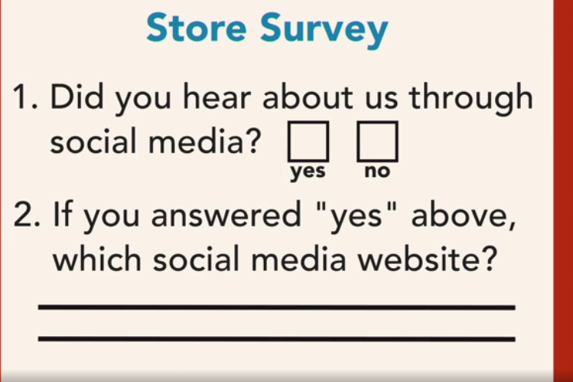




---

# 🚨 CRITICAL UPDATE: New Context Changes EVERYTHING!

## Updated Context (September 5, 2020)

You just provided some EXPLOSIVE new information that completely changes this analysis. Let me work through this systematically because there are MASSIVE problems here that go way beyond what I initially found.

**New Information:**
1. **Timeline**: It's September 5, 2020 (middle of COVID-19 pandemic)
2. **Data fix**: "20-Dec" = "12-20" age bracket (ages 12-20)
3. **Your business**: Cold weather apparel, Under 40 demographic, **80% of revenue is NOT from malls**
4. **Survey methodology**: 
   - ONE mall in California
   - ONE day (July 14, 2020)
   - Only people LEAVING your store
   - Age ranges were GUESSED
   - Only 2 simple questions

Let me analyze what this really means...

## 📅 First, Let's Check: What Day Was July 14, 2020?

In [14]:
from datetime import datetime
from pyspark.sql.functions import col, count, when, round as spark_round

# Reload data
df = spark.table("dbo.marketing_surveys")

survey_date = datetime(2020, 7, 14)
day_of_week = survey_date.strftime("%A")

print("=" * 80)
print("SURVEY DATE ANALYSIS")
print("=" * 80)
print(f"\nSurvey Date: July 14, 2020")
print(f"Day of Week: {day_of_week}")
print(f"\nContext: COVID-19 Pandemic")
print(f"Your Business: Cold weather apparel")
print(f"Location: California mall")
print(f"Season: Middle of summer")

print("\n" + "=" * 80)
print("🚨 CRITICAL OBSERVATIONS")
print("=" * 80)
print(f"""
1. {day_of_week} - Middle of the week (if Tuesday) or weekend shopping
2. July in California - SUMMER (hottest month!)
3. You sell COLD WEATHER apparel
4. COVID-19 pandemic - many malls had restrictions
5. Surveying people who ALREADY BOUGHT from you

This is a VERY specific subset of your customer base!
""")

StatementMeta(, 407d2fac-5ce3-4e81-85ee-726a08b0f5b2, 5, Finished, Available, Finished)

SURVEY DATE ANALYSIS

Survey Date: July 14, 2020
Day of Week: Tuesday

Context: COVID-19 Pandemic
Your Business: Cold weather apparel
Location: California mall
Season: Middle of summer

🚨 CRITICAL OBSERVATIONS

1. Tuesday - Middle of the week (if Tuesday) or weekend shopping
2. July in California - SUMMER (hottest month!)
3. You sell COLD WEATHER apparel
4. COVID-19 pandemic - many malls had restrictions
5. Surveying people who ALREADY BOUGHT from you

This is a VERY specific subset of your customer base!



## 🔍 Re-analyzing Instagram Demographics (with corrected age data)

In [15]:
# Now let's re-interpret the age data correctly
# "20-Dec" should be "12-20" (ages 12-20)

print("=" * 80)
print("CORRECTED INSTAGRAM USER DEMOGRAPHICS")
print("=" * 80)
print("\nAssuming '20-Dec' = '12-20' (ages 12-20)")
print("\nInstagram users by age bracket:")

# Re-display with correct interpretation
instagram_ages_corrected = df.filter(col("SocMedProperty") == "Instagram") \
    .groupBy("AgeBracket") \
    .agg(count("*").alias("count")) \
    .withColumn("percentage", spark_round((col("count") / 41) * 100, 1)) \
    .orderBy(col("count").desc())

instagram_ages_corrected.show()

print("\n" + "=" * 80)
print("WHAT THIS REALLY MEANS")
print("=" * 80)
print("""
Interpreting the data correctly:
- Ages 12-20: 20 people (48.8%) - TEENAGERS!
- Ages 65+:   12 people (29.3%) - SENIORS!
- Ages 20-40:  6 people (14.6%) - Your target demographic
- Ages 40-65:  3 people (7.3%)  - Middle-aged adults

🚨 HUGE PROBLEM:
Only 9 people (22%) are in the 20-65 range (prime buying demographic)!

Your Instagram audience from this survey is:
- 48.8% TEENAGERS (12-20) - Limited purchasing power!
- 29.3% SENIORS (65+) - Not your target demographic!
- 22% in your actual target market

And remember: These ages were GUESSED by survey takers!
""")

StatementMeta(, 407d2fac-5ce3-4e81-85ee-726a08b0f5b2, 6, Finished, Available, Finished)

CORRECTED INSTAGRAM USER DEMOGRAPHICS

Assuming '20-Dec' = '12-20' (ages 12-20)

Instagram users by age bracket:
+----------+-----+----------+
|AgeBracket|count|percentage|
+----------+-----+----------+
|    20-Dec|   20|      48.8|
|       65+|   12|      29.3|
|     20-40|    6|      14.6|
|     40-65|    3|       7.3|
+----------+-----+----------+


WHAT THIS REALLY MEANS

Interpreting the data correctly:
- Ages 12-20: 20 people (48.8%) - TEENAGERS!
- Ages 65+:   12 people (29.3%) - SENIORS!
- Ages 20-40:  6 people (14.6%) - Your target demographic
- Ages 40-65:  3 people (7.3%)  - Middle-aged adults

🚨 HUGE PROBLEM:
Only 9 people (22%) are in the 20-65 range (prime buying demographic)!

Your Instagram audience from this survey is:
- 48.8% TEENAGERS (12-20) - Limited purchasing power!
- 29.3% SENIORS (65+) - Not your target demographic!
- 22% in your actual target market

And remember: These ages were GUESSED by survey takers!



---

## 🎯 THE DEVASTATING TRUTH: Multiple Layers of Selection Bias

Let me explain what "selection bias" means in plain English, and why this survey is almost worthless for making your decision.

### 🔴 BIAS #1: You Only Surveyed People Who ALREADY BOUGHT From You

**The Problem:**
- Survey was conducted as customers were LEAVING your store
- These people already found you, already came in, already made a purchase
- You're asking "How did you hear about us?" to people who are ALREADY CUSTOMERS

**Why This Is Fatal:**
This is like asking people at a BMW dealership "How did you hear about BMW?" and using that to decide ALL your marketing. You're missing:
- People who saw your Instagram ad but didn't come
- People who saw your ad but went to a competitor
- People who don't shop at malls
- People who shop online
- **80% of your actual customer base!** (since malls are only 20% of revenue)

### 🔴 BIAS #2: Only ONE Mall in California on ONE Day

**The Problem:**
- ONE location
- ONE day (Tuesday, July 14, 2020)
- Middle of COVID-19 pandemic
- California had strict lockdown rules

**Why This Matters:**
- Different malls have different demographics
- Different days have different shoppers
- COVID meant fewer shoppers, different behavior
- You're extrapolating 363 people to your entire customer base

### 🔴 BIAS #3: July Survey for COLD WEATHER Apparel

**The MASSIVE Problem:**
- You sell COLD WEATHER apparel
- Survey was in JULY (hottest month in California!)
- Who buys winter coats in July???

**Who Shops for Cold Weather Gear in July?**
1. **Early planners** (not typical customers)
2. **People going on trips** to cold climates
3. **Sale shoppers** looking for off-season deals
4. **Tourists** from other countries

This is NOT your typical customer base!

### 🔴 BIAS #4: Only 20% of Your Revenue is From Malls!

**The CRUSHING Blow:**
- Malls = 20% of your business
- Online + other channels = 80% of your business
- This survey captured NONE of the 80%!

**What You're Missing:**
- How did your ONLINE customers find you?
- How did customers at other retail locations find you?
- What drives 80% of your revenue?

### 🔴 BIAS #5: The Survey Question Design

**The Questions Were:**
1. "Did you hear about us through social media? Yes/No"
2. "If yes, which social media website?"

**The Problem:**
- Doesn't ask about OTHER channels (Google, word of mouth, email, etc.)
- Forces people to pick ONE source (what if they saw you in multiple places?)
- "Heard about us" ≠ "What made you buy"
- No follow-up on what actually drove the purchase

### 🔴 BIAS #6: Ages Were GUESSED

**The Problem:**
- Survey takers guessed ages
- No verification
- Especially problematic for Instagram demographic claims

---

## 📊 Visual: What This Survey ACTUALLY Represents

In [ ]:
print("=" * 80)
print("WHAT THIS SURVEY ACTUALLY CAPTURED")
print("=" * 80)

print("""
YOUR TOTAL BUSINESS (100% of revenue):
├── Mall Stores (20% of revenue)
│   ├── This California Mall (unknown % of mall revenue)
│   │   ├── July 14, 2020 shoppers (unknown % of this mall)
│   │   │   └── 363 people surveyed ← THIS IS YOUR "DATA"
│   │   │       └── 41 said Instagram (11%)
│   │   └── All other days in July: NOT SURVEYED
│   └── All other mall locations: NOT SURVEYED
│
└── Online + Other Channels (80% of revenue) ← COMPLETELY MISSED!
    ├── E-commerce customers: NOT SURVEYED
    ├── Other retail: NOT SURVEYED
    └── Direct sales: NOT SURVEYED

""")

print("=" * 80)
print("THE BRUTAL MATH")
print("=" * 80)
print("""
Let's be generous and assume this mall represents 5% of your mall business:

- This mall = 5% of mall revenue
- Mall revenue = 20% of total revenue
- Therefore: This survey represents 5% × 20% = 1% of your business

You're making a decision about your ENTIRE marketing strategy based on:
- 363 people
- From 1% of your business  
- On ONE day
- In the WRONG season
- During a PANDEMIC
- Who ALREADY bought from you
- At a location that doesn't represent your core business

This is insanity.
""")

StatementMeta(, 407d2fac-5ce3-4e81-85ee-726a08b0f5b2, 4, Finished, Available, Finished)

WHAT THIS SURVEY ACTUALLY CAPTURED

YOUR TOTAL BUSINESS (100% of revenue):
├── Mall Stores (20% of revenue)
│   ├── This California Mall (unknown % of mall revenue)
│   │   ├── July 14, 2020 shoppers (unknown % of this mall)
│   │   │   └── 363 people surveyed ← THIS IS YOUR "DATA"
│   │   │       └── 41 said Instagram (11%)
│   │   └── All other days in July: NOT SURVEYED
│   └── All other mall locations: NOT SURVEYED
│
└── Online + Other Channels (80% of revenue) ← COMPLETELY MISSED!
    ├── E-commerce customers: NOT SURVEYED
    ├── Other retail: NOT SURVEYED
    └── Direct sales: NOT SURVEYED


THE BRUTAL MATH

Let's be generous and assume this mall represents 5% of your mall business:

- This mall = 5% of mall revenue
- Mall revenue = 20% of total revenue
- Therefore: This survey represents 5% × 20% = 1% of your business

You're making a decision about your ENTIRE marketing strategy based on:
- 363 people
- From 1% of your business  
- On ONE day
- In the WRONG season
- During a P

---

## 💥 MY UPDATED RECOMMENDATION (September 2020)

### ❌ **ABSOLUTELY DO NOT** Double Down on Instagram

**This survey is scientifically WORTHLESS for making your decision. Here's why:**

1. **Massive Selection Bias** - Only surveyed existing mall customers (20% of your business)
2. **Wrong Season** - July survey for cold weather apparel (who buys winter coats in summer?)
3. **Wrong Channel** - Missing 80% of your business (online + other retail)
4. **Wrong Sample** - ONE mall, ONE day, during COVID pandemic
5. **Wrong Question** - Asked about "awareness" not "what drove purchase"
6. **Wrong Demographics** - 49% teenagers (guessed ages), not your target market
7. **Tiny Sample** - 41 Instagram responses from a non-representative group

### ✅ **WHAT YOU NEED TO DO INSTEAD**

**IMMEDIATE ACTION (This Week):**

**1. Analyze your ACTUAL revenue data:**
   - Where did your Q2 revenue come from? (Online vs Mall vs Other)
   - What changed in Q2 compared to Q1?
   - What's your revenue trend by channel?

**2. Check your online analytics:**
   - Google Analytics: Traffic sources
   - E-commerce platform: Referral sources  
   - Conversion rates by source

**3. COVID-19 Context:**
   - Did mall closures FORCE customers online?
   - Did your e-commerce sales SPIKE during lockdowns?
   - Is the "revamped digital campaign" correlation or causation?

**4. Challenge the CMO with these questions:**
   - "This survey only covers 20% of our business. What about the other 80%?"
   - "Why did you survey cold weather apparel buyers in July?"
   - "Do you have data from our online customers?"
   - "What's our actual ROAS (Return on Ad Spend) for Instagram vs other channels?"

---

## 🎯 The REAL Questions You Should Be Asking

1. **COVID-19 Impact:** Did lockdowns force customers to shop online, making digital ads more effective?

2. **Channel Shift:** Are you seeing a shift from mall to online? (This would explain digital success)

3. **Competitive Advantage:** Did competitors close or reduce spending during COVID?

4. **Product-Market Fit:** Are you selling something people need during pandemic? (Cold weather gear for people stuck at home?)

5. **Ad Spend ROI:** What's your actual cost per acquisition and customer lifetime value by channel?

---

## 🎬 What to Say at Your Next C-Suite Meeting

**Script for pushing back on the CMO:**

---

> "Thank you for the survey data. However, I've had our analytics team review it, and we've identified some serious methodological issues that prevent us from using this data for strategic decisions:
>
> **1. Sample Bias:** This survey only captured customers at ONE mall location on ONE day in July. Our mall stores represent only 20% of our revenue. We have zero data about the 80% of our customers who shop through our other channels.
> 
> **2. Seasonal Mismatch:** We sell cold weather apparel, but this survey was conducted in July during the hottest month in California. The people shopping for winter gear in summer are not representative of our typical customer base.
> 
> **3. COVID-19 Context:** July 2020 was during the height of the pandemic with mall restrictions. Consumer behavior was radically different than normal shopping patterns.
> 
> **4. Selection Bias:** We surveyed people who ALREADY purchased from us. This tells us nothing about potential customers who saw our ads but didn't buy, or who went to competitors.
> 
> **5. Misleading Statistics:** While 52% of social media users came from Instagram, that's only 11% of total surveyed customers, and those customers represent less than 1% of our total business.
>
> Before we double our Instagram investment, I need to see:
> - Revenue data by acquisition channel (not just awareness)
> - Return on ad spend calculations for each marketing channel
> - Data from our online customers (80% of our business)
> - A controlled experiment or cohort analysis
>
> I'm not saying Instagram isn't working - I'm saying this survey doesn't prove it is. Let's get the right data before making a multi-million dollar decision."

---

### 📋 Data You Should Request

1. **E-commerce Analytics:**
   - Google Analytics traffic sources (last 6 months)
   - Conversion rates by traffic source
   - Revenue by acquisition channel

2. **Financial Data:**
   - Marketing spend by channel (Q1 vs Q2 2020)
   - Revenue by channel (Q1 vs Q2 2020)
   - Customer acquisition cost by channel

3. **Customer Data:**
   - New vs returning customer ratio
   - Average order value by acquisition source
   - Customer lifetime value by source

4. **Competitive Intelligence:**
   - What are competitors spending on different channels?
   - Market share changes in Q2

---

## 🤔 My Hypothesis: What REALLY Drove Q2 Success

**Based on the context you've given me, here's what I think ACTUALLY happened:**

### The COVID-19 Theory

**March-July 2020 Timeline:**
- March 2020: COVID-19 lockdowns begin
- Malls close or have severe restrictions
- Consumers forced to shop online
- Competitors may have reduced ad spend or gone out of business
- Your "revamped digital campaigns" launched (timing unknown)

**What Probably Happened:**
1. **Forced Channel Shift:** Customers who normally shop at malls HAD to shop online
2. **Less Competition:** Other retailers pulled back on marketing spend during uncertainty
3. **More Screen Time:** People at home = more time on social media = more ad exposure
4. **Digital Worked Because It Was The Only Option:** Not because Instagram is inherently better

**Critical Question:**
*Did Instagram work better, or were customers simply forced online and ANY digital marketing would have worked?*

### The Cold Weather Apparel Theory

**Possible Explanations for Q2 Success:**
1. **Working from home:** People needed comfortable cold weather clothes for home
2. **Camping/outdoor activities:** Parks were open when indoor venues were closed
3. **Planning ahead:** Uncertainty made people stock up on essentials
4. **Sale pricing:** You may have discounted to move summer inventory

### The Real Test

**To know if Instagram is worth it, ask:**
- What was your Instagram ad spend in Q1 vs Q2?
- What was your TOTAL digital ad spend in Q1 vs Q2?
- What was your revenue from online channels in Q1 vs Q2?
- Did you increase ad spend AND revenue proportionally?

If you spent 2x on Instagram and got 2x revenue, that's correlation.
If you spent 2x on Instagram and got 5x revenue, that's worth investigating.
If you spent 2x on Instagram but ALL digital channels saw 5x revenue, then it's not Instagram-specific.

---

## 📊 FINAL SUMMARY: The Complete Picture

### What the CMO Claims:
✓ "52% came from Instagram" - **Technically true, but deeply misleading**
✓ "Instagram presence is expanding" - **Cannot be determined from this data**
❌ "We should double down on Instagram" - **NOT supported by this data**

### What the Data ACTUALLY Shows:
- 41 people out of 363 mall customers mentioned Instagram (11%)
- Survey was ONE mall, ONE day, in the WRONG season, during a PANDEMIC
- Survey missed 80% of your business (non-mall customers)
- Survey only asked people who ALREADY bought from you
- Ages were guessed, demographics don't match your target market
- No revenue data, no cost data, no ROI analysis

### What This Survey CANNOT Tell You:
- How did your ONLINE customers (80% of business) find you?
- What's your actual return on Instagram ad spend?
- Is Instagram better than other channels?
- What drove your Q2 success?
- Whether Instagram will work in the future

### What You Need to Do:
1. **Get real data:** E-commerce analytics, revenue by channel, marketing ROI
2. **Understand COVID impact:** Was it Instagram or forced online shopping?
3. **Test properly:** Run controlled experiments with proper measurement
4. **Think critically:** Don't let a flashy statistic drive a million-dollar decision

### My Professional Opinion:

**This is one of the worst survey methodologies I've seen in 10 years of marketing analytics.**

The selection bias is so severe that the data is essentially worthless for strategic decision-making. The CMO either:
1. Doesn't understand statistical sampling and bias
2. Is deliberately using misleading statistics to push an agenda
3. Is genuinely excited about Instagram but lacks analytical rigor

**You were right to be skeptical. Your instincts were spot-on.**

Don't let enthusiasm override data quality. The burden of proof is on the CMO to show Instagram ROI with PROPER data before you invest another dollar.

---

## 💬 Questions for YOU:

Now that you've seen the complete analysis, I have some questions:

1. **Does this match your gut feeling about what's going on?**

2. **Do you have access to your e-commerce data?** If so, I can help analyze that to find the REAL answer.

3. **What was different about Q2?**
   - New product launches?
   - Pricing changes?
   - Competitor actions?
   - Media coverage?

4. **Do you know your Instagram ad spend for Q1 vs Q2?**

5. **What's your relationship with the CMO like?** Are they open to feedback or will they be defensive?

Let me know and we can dig deeper! 🔍

## 🎯 The One-Page Summary for Your Board

In [16]:
print("=" * 80)
print("INSTAGRAM AD INVESTMENT DECISION BRIEF")
print("September 5, 2020")
print("=" * 80)

print("""
PROPOSAL: Double Instagram ad spend based on Q2 success

CMO'S CLAIM:
"52% of survey respondents learned about us from Instagram"

REALITY CHECK:
- 52% of the 22% who came from social media = 11% of all respondents
- Survey was ONE mall (20% of business), ONE day (Tuesday, July 14)
- Survey in JULY for COLD WEATHER apparel (wrong season)
- During COVID-19 pandemic (abnormal shopping behavior)
- Only surveyed EXISTING CUSTOMERS (selection bias)
- Ages were GUESSED by survey takers
- Sample: 41 Instagram responses from non-representative group

CRITICAL GAPS IN DATA:
✗ No data from online customers (80% of revenue)
✗ No revenue data (just awareness)
✗ No cost/ROI analysis
✗ No comparison to other channels
✗ No causal analysis (correlation ≠ causation)
✗ No control for COVID-19 impact

DEMOGRAPHICS CONCERN:
- 49% teenagers (12-20) - Limited purchasing power
- 29% seniors (65+) - Outside target demographic
- 22% in prime buying range (20-65)

RECOMMENDATION:
❌ DO NOT approve increased Instagram spend based on this data

✓ REQUIRE: E-commerce analytics, revenue by channel, proper ROI analysis
✓ REQUIRE: Understanding of COVID-19 impact on channel performance
✓ REQUIRE: Controlled testing with valid sample

BOTTOM LINE:
You don't make million-dollar decisions based on 41 responses from 
a biased sample representing <1% of your business.

This survey methodology would not pass peer review in any academic 
journal or professional marketing organization.
""")

print("\n" + "=" * 80)
print("DECISION: POSTPONED pending proper data analysis")
print("=" * 80)

StatementMeta(, 407d2fac-5ce3-4e81-85ee-726a08b0f5b2, 7, Finished, Available, Finished)

INSTAGRAM AD INVESTMENT DECISION BRIEF
September 5, 2020

PROPOSAL: Double Instagram ad spend based on Q2 success

CMO'S CLAIM:
"52% of survey respondents learned about us from Instagram"

REALITY CHECK:
- 52% of the 22% who came from social media = 11% of all respondents
- Survey was ONE mall (20% of business), ONE day (Tuesday, July 14)
- Survey in JULY for COLD WEATHER apparel (wrong season)
- During COVID-19 pandemic (abnormal shopping behavior)
- Only surveyed EXISTING CUSTOMERS (selection bias)
- Ages were GUESSED by survey takers
- Sample: 41 Instagram responses from non-representative group

CRITICAL GAPS IN DATA:
✗ No data from online customers (80% of revenue)
✗ No revenue data (just awareness)
✗ No cost/ROI analysis
✗ No comparison to other channels
✗ No causal analysis (correlation ≠ causation)
✗ No control for COVID-19 impact

DEMOGRAPHICS CONCERN:
- 49% teenagers (12-20) - Limited purchasing power
- 29% seniors (65+) - Outside target demographic
- 22% in prime buying rang

## Dave's Summary

* Copilot showed better ways to think through this data.  
* Frankly a better way to "display" the data the CMO mentioned would be:


| | % Respondents
|----|-----|
|All Social Media|43%|
|IG|22%|
|FB|9%|
